# **PORTUGESE STUDENTS**

## Imports

In [256]:
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from models import train_linear_model, train_logistic_model
from sklearn.metrics import accuracy_score
from data import category_split, balance_feature, frame_status_info
from evaluation import evaluate_model, plot_model_acc_and_fscore, display_model_weights, evaluate_model_thresholded_regression, evaluate_model_classifier

## Settings

In [257]:
DATA_RELATIVE_PATH = "data/student_portugal/combined_noDup_processed.csv"

TARGET_COLUMN = "G1"
TARGET_OPERTOR = "<" #Does not change the training, only splits
TARGET_VALUE = 10


RANDOM_SEED = 11032004
SPLIT_PERCENTAGE_TESTING = 0.12

BALANCE_DATA = True
BALANCE_QUERY = TARGET_COLUMN + " " + TARGET_OPERTOR + " " + str(TARGET_VALUE)
BALANCE_QUERY_NON_TARGET_PERCENTAGE = 0.50


REGULARIZER_WEIGTH = 0.01
#MODEL_THERESHOLD_REG = TARGET_VALUE
MODEL_THERESHOLD_LOG = 0.5

DEBUG_MODE = True


## Loading the Data

In [258]:
# Load dataset
data_file = os.path.join(os.getcwd(), DATA_RELATIVE_PATH)
df = pd.read_csv(data_file)
print("Loaded datafile")
print(df.shape)

Loaded datafile
(662, 45)


# Data processing

### Irrelevant data

In [259]:
#Remove constant columns
df = df.loc[:, df.nunique() > 1]

### Identical Data

In [260]:
# Ensure all rows are unique
df = df.drop_duplicates()
print("Removed duplicate rows")

Removed duplicate rows


### Missing data

In [261]:
# All data is present in this dataframe.

## Feature Processing

In [262]:
#Remove columns
columns_to_remove = ["school", "sex", "G2", "G3"]
df.drop(columns=columns_to_remove, inplace=True, errors='ignore')

## Splitting data

### Split

In [263]:
train_df, test_df = train_test_split(df, test_size=SPLIT_PERCENTAGE_TESTING, random_state=RANDOM_SEED)
frame_status_info(train_df, test_df)

Training data shape: (582, 41)
Testing data shape: (80, 41)


### Balance

In [264]:
if (BALANCE_DATA):
    match_df, no_match_df = category_split(train_df, BALANCE_QUERY)
    train_balanced = balance_feature(match_df, no_match_df, BALANCE_QUERY_NON_TARGET_PERCENTAGE)

## Training

### Preparation

In [265]:
# Define features and target variable
temp_train : pd.DataFrame = train_balanced if BALANCE_DATA else train_df

frame_status_info(temp_train, test_df)
print("Training percentage:", test_df.shape[0]/temp_train.shape[0])

X_train = temp_train.drop(columns=[TARGET_COLUMN]).values
y_train_reg = temp_train[TARGET_COLUMN]
y_train_cls = (temp_train[TARGET_COLUMN] < TARGET_VALUE).astype(int)

X_test = test_df.drop(columns=[TARGET_COLUMN]).values
y_test_reg = test_df[TARGET_COLUMN]
y_test_cls = (test_df[TARGET_COLUMN] < TARGET_VALUE).astype(int)

Training data shape: (214, 41)
Testing data shape: (80, 41)
Training percentage: 0.37383177570093457


### Execution

In [266]:
# Train regression models
print("Training RegN")
model_reg_no = train_linear_model(X_train, y_train_reg.values, reg_type=None)  # Standard
print("Training Reg1")
model_reg_l1 = train_linear_model(X_train, y_train_reg.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Reg2")
model_reg_l2 = train_linear_model(X_train, y_train_reg.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

# Train logistic models
print("Training LogN")
model_log_no = train_logistic_model(X_train, y_train_cls.values, reg_type=None)  # Standard
print("Training Log1")
model_log_l1 = train_logistic_model(X_train, y_train_cls.values, reg_type="l1", alpha=REGULARIZER_WEIGTH)  # Lasso
print("Training Log2")
model_log_l2 = train_logistic_model(X_train, y_train_cls.values, reg_type="l2", alpha=REGULARIZER_WEIGTH)  # Ridge

Training RegN
Training Reg1
Training Reg2
Training LogN
Training Log1
Training Log2


## Evaluation

### Execution

Regression Models:
[Standard Linear Regression] Sample predicted scores: [ 1.42396758e+10 -2.17258093e+13 -1.79234944e+13  1.98947002e+13
  6.66705830e+13  4.95456862e+12 -9.36767073e+12 -1.82703102e+13
 -1.53552304e+13 -1.08545907e+13]
[Standard Linear Regression] Applied threshold: 10
[Standard Linear Regression] Predicted labels: [False  True  True False False False  True  True  True  True]
[Standard Linear Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Standard Linear Regression] Accuracy: 0.375
[Standard Linear Regression] F1 Score: 0.43181818181818177


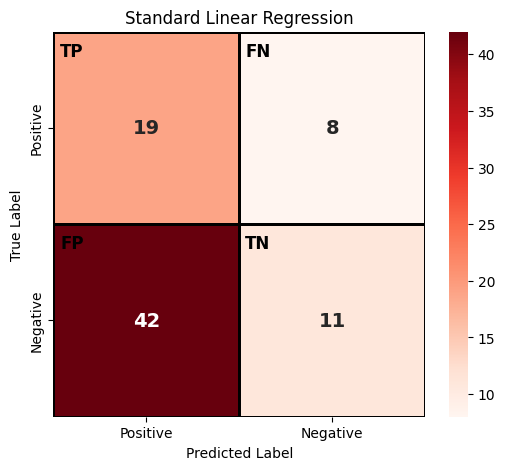

[Lasso Regression] Sample predicted scores: [11.98700416 13.16984593 14.5667384   9.89662968 12.7726356  12.008065
 12.89851068 11.43963523 14.88387126 11.17126427]
[Lasso Regression] Applied threshold: 10
[Lasso Regression] Predicted labels: [False False False  True False False False False False False]
[Lasso Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Lasso Regression] Accuracy: 0.7125
[Lasso Regression] F1 Score: 0.25806451612903225


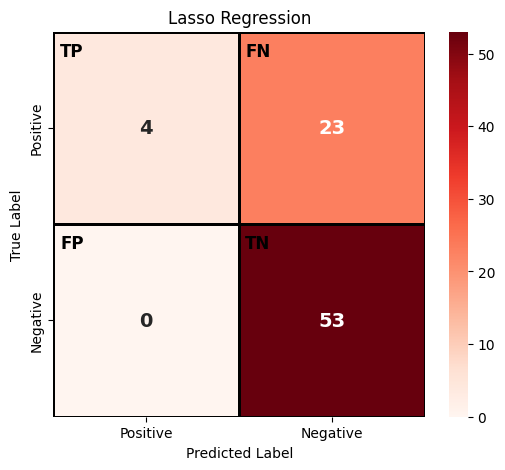

[Ridge Regression] Sample predicted scores: [12.95304109 11.5366193  13.48809964 16.52914689 22.29851296 14.3927681
 13.36178654 11.76674024 13.23365042 11.2403608 ]
[Ridge Regression] Applied threshold: 10
[Ridge Regression] Predicted labels: [False False False False False False False False False False]
[Ridge Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Ridge Regression] Accuracy: 0.725
[Ridge Regression] F1 Score: 0.3125


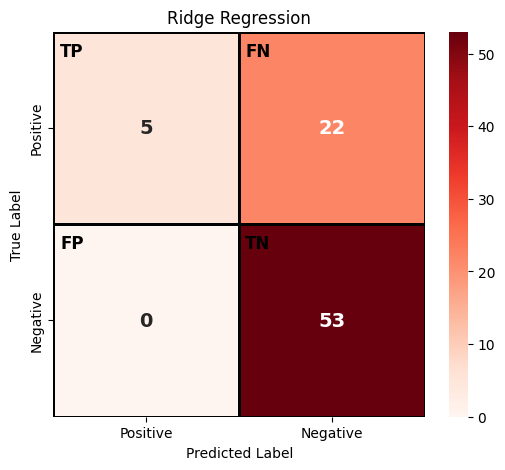

Logistic Models:
[Standard Logistic Regression] Sample predicted probabilities: [0.99999996 1.         0.99990603 0.99999932 0.99999893 0.98458574
 0.78964169 1.         0.95958273 1.        ]
[Standard Logistic Regression] Applied threshold: 0.5
[Standard Logistic Regression] Predicted labels: [ True  True  True  True  True  True  True  True  True  True]
[Standard Logistic Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Standard Logistic Regression] Accuracy: 0.3625
[Standard Logistic Regression] F1 Score: 0.49504950495049505


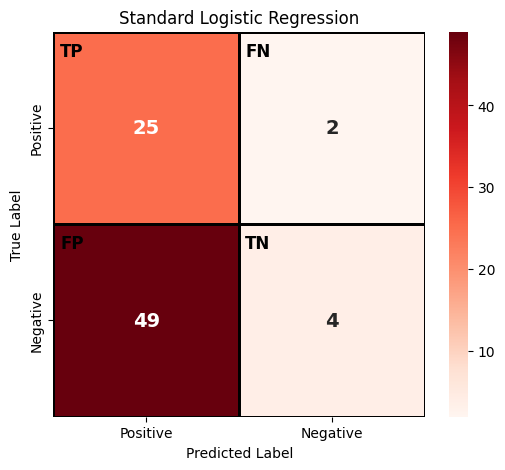

[Lasso Logistic Regression] Sample predicted probabilities: [0.29088156 0.52893413 0.26091412 0.74465887 0.194707   0.40725163
 0.40218138 0.67437839 0.21723497 0.74217397]
[Lasso Logistic Regression] Applied threshold: 0.5
[Lasso Logistic Regression] Predicted labels: [False  True False  True False False False  True False  True]
[Lasso Logistic Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Lasso Logistic Regression] Accuracy: 0.825
[Lasso Logistic Regression] F1 Score: 0.7407407407407407


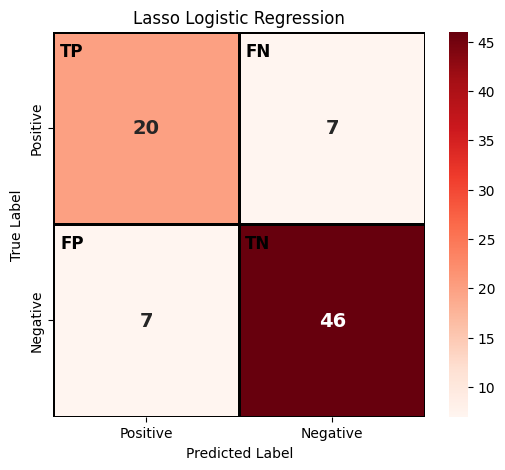

[Ridge Logistic Regression] Sample predicted probabilities: [0.14175346 0.41781321 0.15529978 0.17225294 0.00454858 0.13590622
 0.23572731 0.47862213 0.12846744 0.50682133]
[Ridge Logistic Regression] Applied threshold: 0.5
[Ridge Logistic Regression] Predicted labels: [False False False False False False False False False  True]
[Ridge Logistic Regression] Sample true values: [0 1 0 1 0 0 0 0 0 1]
[Ridge Logistic Regression] Accuracy: 0.8
[Ridge Logistic Regression] F1 Score: 0.6


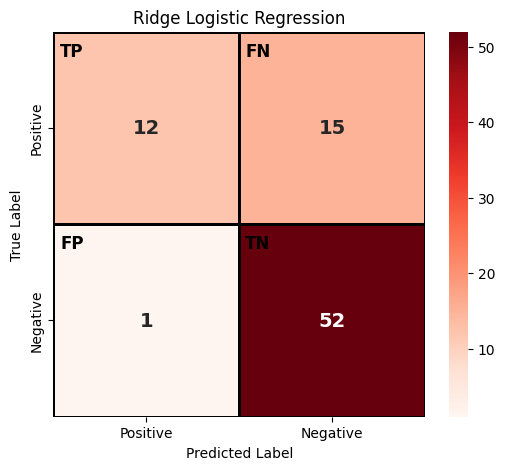

In [267]:
# Evaluate regression models
print("Regression Models:")
acc_reg_no, f_reg_no = evaluate_model_thresholded_regression(model_reg_no, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Standard Linear Regression", debug=DEBUG_MODE)
acc_reg_l1, f_reg_l1 = evaluate_model_thresholded_regression(model_reg_l1, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Lasso Regression", debug=DEBUG_MODE)
acc_reg_l2, f_reg_l2 = evaluate_model_thresholded_regression(model_reg_l2, X_test, (y_test_reg < TARGET_VALUE).astype(int), TARGET_VALUE, "Ridge Regression", debug=DEBUG_MODE)

# Evaluate logistic models
print("Logistic Models:")
acc_log_no, f_log_no = evaluate_model_classifier(model_log_no, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Standard Logistic Regression", debug=DEBUG_MODE)
acc_log_l1, f_log_l1 = evaluate_model_classifier(model_log_l1, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Lasso Logistic Regression", debug=DEBUG_MODE)
acc_log_l2, f_log_l2 = evaluate_model_classifier(model_log_l2, X_test, y_test_cls, MODEL_THERESHOLD_LOG, "Ridge Logistic Regression", debug=DEBUG_MODE)

### Analysis

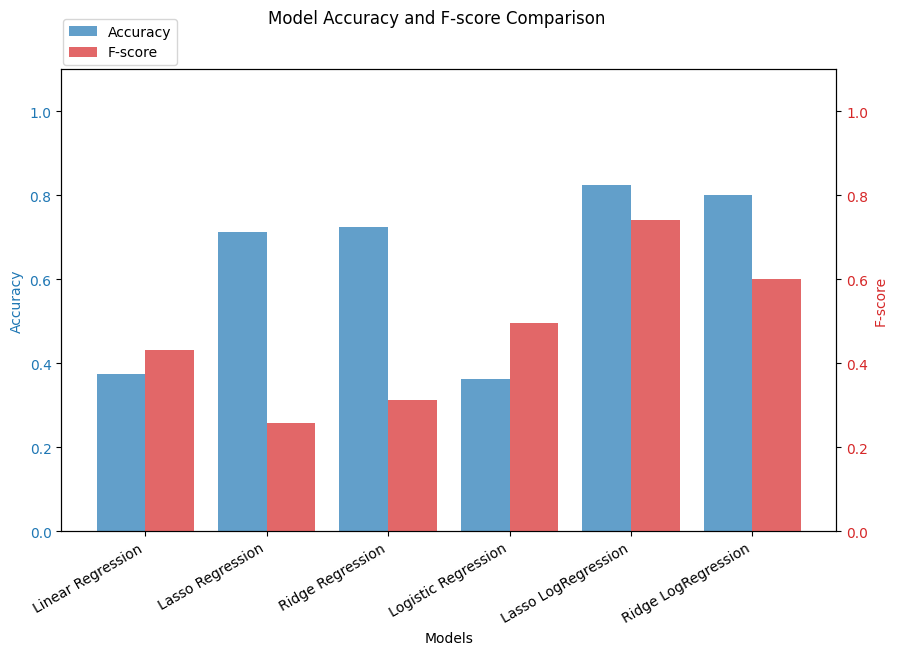

In [268]:
accs = [acc_reg_no, acc_reg_l1, acc_reg_l2, acc_log_no, acc_log_l1, acc_log_l2]
fscores = [f_reg_no, f_reg_l1, f_reg_l2, f_log_no, f_log_l1, f_log_l2]
model_names = ["Linear Regression", "Lasso Regression", "Ridge Regression",
               "Logistic Regression", "Lasso LogRegression", "Ridge LogRegression"]
plot_model_acc_and_fscore(accs, fscores, model_names)

### Weights

In [269]:
display_model_weights(model_reg_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

           Feature  Absolute value weight    Weight
7         failures               1.002940 -1.002940
3             Medu               0.618848  0.618848
24     FjobTeacher               0.574249  0.574249
9           famsup               0.554230 -0.554230
6        studytime               0.534516  0.534516
37  guardianMother               0.441407 -0.441407
36     reasonOther               0.429329 -0.429329
2          Pstatus               0.361044  0.361044
8        schoolsup               0.330824 -0.330824
18           goout               0.286862 -0.286862
Displayed sorted feature weights


In [270]:
display_model_weights(model_log_l1, train_df.drop(columns=[TARGET_COLUMN]), num_features=10)

           Feature  Absolute value weight    Weight
7         failures               1.029292  1.029292
37  guardianMother               0.285430  0.285430
27    MjobServices               0.271771 -0.271771
9           famsup               0.247855  0.247855
4             Fedu               0.226402 -0.226402
10            paid               0.203754  0.203754
8        schoolsup               0.184616  0.184616
38  guardianFather               0.172984 -0.172984
6        studytime               0.172467 -0.172467
36     reasonOther               0.140295  0.140295
Displayed sorted feature weights
